# 10. Customer group

## 1. Setup and Load Dataset

In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data, load_raw_data, save_file
from src.splitting import time_train_test_split
from src.evaluation import evaluate
# Clustering libraries
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.10.20
Pandas version: 2.3.3
NumPy version: 2.2.5


In [40]:
# Load raw data using custom loader
try:
    df = load_raw_data()
    print("✅ Data loaded successfully!")
    print(f"📊 Shape: {df.shape}")
    print(f"🕒 Time span: {df.index.min()} → {df.index.max()}")
    print(f"🕒 Frequency: {df.index.freq if df.index.freq else 'Not set'}")
except Exception as e:
    print(f"❌ Error: {e}")

👉 Loading: data\raw\electricity_data.parquet
✅ Data loaded successfully!
📊 Shape: (140256, 370)
🕒 Time span: 2011-01-01 00:15:00 → 2015-01-01 00:00:00
🕒 Frequency: Not set


## Chia train/test

In [41]:
# ensure datetime + sort
df.index = pd.to_datetime(df.index)
df = df.sort_index()
# chia train/test theo mốc thời gian, bỏ năm 2011
split_point = pd.Timestamp("2014-01-01 00:00:00")
train_raw = df[df.index < split_point].copy()
test_raw  = df[(df.index >= split_point) & (df.index < pd.Timestamp("2015-01-01 00:00:00"))].copy()

# resample 15min -> hourly riêng từng tập
train_df_h = train_raw.resample("1h").sum()
test_df_h  = test_raw.resample("1h").sum()

# fill/interpolate riêng từng tập để không nhìn sang tương lai
train_df_h = train_df_h.interpolate(method="time")
test_df_h  = test_df_h.interpolate(method="time")

# Xử lý Nan values
train_df_h = train_df_h.ffill().bfill()
test_df_h  = test_df_h.ffill()

print("Done split + resample safely")
print("Train:", train_df_h.shape, train_df_h.index.min(), "->", train_df_h.index.max())
print("Test :", test_df_h.shape, test_df_h.index.min(), "->", test_df_h.index.max())


Done split + resample safely
Train: (26304, 370) 2011-01-01 00:00:00 -> 2013-12-31 23:00:00
Test : (8760, 370) 2014-01-01 00:00:00 -> 2014-12-31 23:00:00


## Kiểm tra KH không bao giờ sử dụng điện (có thể bị xóa sau khi preprocessing)

In [42]:
train_zero = train_raw.columns[train_raw.sum(axis=0) == 0]
test_zero  = test_raw.columns[test_raw.sum(axis=0) == 0]
common_zero = set(train_zero) & set(test_zero)

print("Train full-zero:", len(train_zero))
print("Test full-zero:", len(test_zero))
print("Overlap full-zero:", len(common_zero))

print("Common customers:", common_zero)

Train full-zero: 19
Test full-zero: 1
Overlap full-zero: 0
Common customers: set()


## Visualize tập train/test trước khi chia nhóm

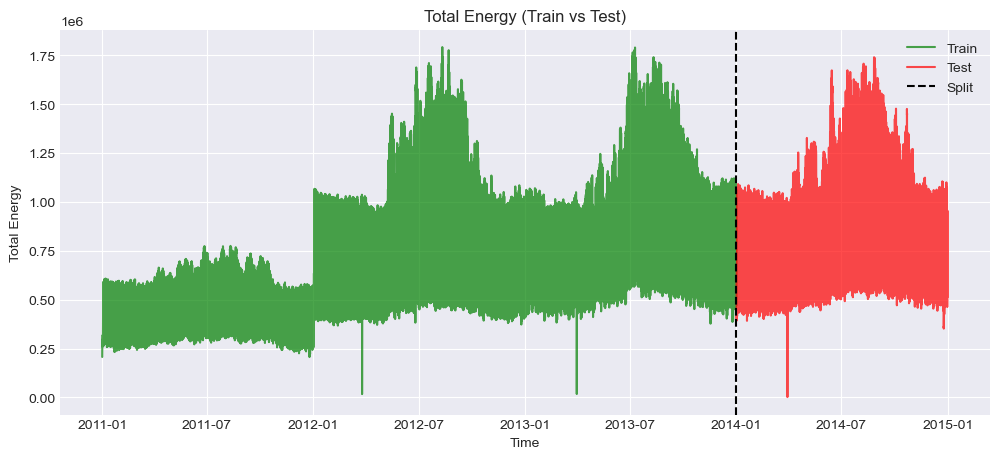

In [43]:
train_df_h["total_energy"] = train_df_h.sum(axis=1)
test_df_h["total_energy"]  = test_df_h.sum(axis=1)
plt.figure(figsize=(12,5))
plt.plot(train_df_h.index, train_df_h['total_energy'], label='Train', color='green', alpha=0.7)
plt.plot(test_df_h.index, test_df_h['total_energy'], label='Test', color='red', alpha=0.7)
plt.axvline(train_df_h.index[-1], color='black', linestyle='--', label='Split')
plt.legend()
plt.title("Total Energy (Train vs Test)")
plt.xlabel("Time")
plt.ylabel("Total Energy")

plt.show()

## Tiền xử lý  

In [44]:
# xác định structural zeros
def detect_first_active(series, min_active_points=24):
    """
    Tìm thời điểm customer thực sự bắt đầu hoạt động
    (không phải chỉ 1 điểm noise)
    """
    # rolling để tránh noise
    active = series > 0
    rolling = active.rolling(min_active_points).sum()
    idx = rolling[rolling >= min_active_points].index
    return idx[0] if len(idx) > 0 else series.index[0]
first_active = train_df_h.apply(detect_first_active)

# mask structural zeros
train_clean = train_df_h.copy()
test_clean  = test_df_h.copy()
train_clean = train_clean.loc[:, train_clean.columns != "total_energy"]
test_clean  = test_clean.loc[:, test_clean.columns != "total_energy"]
for col in train_df_h.columns:
    start = first_active[col]
    
    if pd.notna(start):
        # chỉ xoá nếu trước đó toàn 0
        mask = train_df_h.index < start
        if (train_df_h.loc[:start, col] == 0).mean() > 0.95:
            train_clean.loc[train_clean.index < start, col] = np.nan

# test apply theo train
for col in test_df_h.columns:
    start = first_active[col]
    if pd.notna(start):
        test_clean.loc[test_clean.index < start, col] = np.nan
# fill/interpolate riêng từng tập để không nhìn sang tương lai
train_clean = train_clean.ffill()
test_clean  = test_clean.ffill()
# xử lý outliers: dùng quantile để tránh extreme spikes
lower = train_clean.quantile(0.01)
upper = train_clean.quantile(0.99)

train_clean = train_clean.clip(lower=lower, upper=upper, axis=1)
test_clean  = test_clean.clip(lower=lower, upper=upper, axis=1)

# in kết quả
print("NaN train:", train_clean.isna().sum().sum())
print("NaN test :", test_clean.isna().sum().sum())

print("Train shape:", train_clean.shape)
print("Test shape :", test_clean.shape)
print("Customers  :", train_clean.shape[1])

# giá trị 0
zero_before = (train_raw == 0).sum().sum()
total_values_before = train_raw.size
zero_after = (train_clean == 0).sum().sum()
total_values_after = train_clean.size
print("Zero ratio before preprocessing:", zero_before / total_values_before)
print("Total zeros before preprocessing:", zero_before)
print("Zero ratio after preprocessing:", zero_after / total_values_after)
print("Total zeros after preprocessing:", zero_after)

NaN train: 1978354
NaN test : 8760
Train shape: (26304, 370)
Test shape : (8760, 371)
Customers  : 370
Zero ratio before preprocessing: 0.2624725176633175
Total zeros before preprocessing: 10217937
Zero ratio after preprocessing: 0.058644661997764184
Total zeros after preprocessing: 570758


## Save cleaned file

In [45]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().parent

DATA_ROOT = BASE_DIR / "data" / "processed"
method_name = "clean_data"

base_path = DATA_ROOT / method_name
base_path.mkdir(parents=True, exist_ok=True)

train_file = base_path / "train_clean.csv"
test_file  = base_path / "test_clean.csv"

train_clean.to_csv(train_file)
test_clean.to_csv(test_file)

print("Saved clean data:")
print(train_file)
print(test_file)

Saved clean data:
c:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\clean_data\train_clean.csv
c:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\clean_data\test_clean.csv


# Các Phương pháp phân loại

## 1. clustering theo shape (KMeans + normalize theo user)

In [46]:
# mỗi customer = 1 vector time-series
X_ts = train_clean.T.copy()   # (customers x time)

# normalize theo từng user (giữ shape, bỏ scale)
X_ts = X_ts.div(X_ts.mean(axis=1) + 1e-8, axis=0)

# xử lý NaN
X_ts = X_ts.fillna(0)

X_values = X_ts.values

results = []
dist_dict = {}

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_values)

    # metrics
    sil = silhouette_score(X_values, labels)
    ch  = calinski_harabasz_score(X_values, labels)
    db  = davies_bouldin_score(X_values, labels)

    results.append({
        "K": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })

    # distribution
    dist = pd.Series(labels).value_counts().sort_index()
    dist_dict[k] = dist

# tables
kmeans_results_df = pd.DataFrame(results)

print("\nSHAPE KMEANS METRICS TABLE ")
print(kmeans_results_df.to_string(index=False))

dist_table = pd.DataFrame(dist_dict).fillna(0).astype(int).T
dist_table.index.name = "K"

print("\nSHAPE KMEANS DISTRIBUTION TABLE")
print(dist_table)



SHAPE KMEANS METRICS TABLE 
 K  silhouette  calinski_harabasz  davies_bouldin
 2    0.453228         226.188440        0.917142
 3    0.520489         217.391883        0.862712
 4    0.524756         177.474314        0.671107
 5    0.470646         158.225335        0.925656
 6    0.462725         146.291949        0.814757
 7    0.467483         139.127997        0.853125
 8    0.474320         130.649993        0.761563

SHAPE KMEANS DISTRIBUTION TABLE
     0    1    2   3    4  5   6  7
K                                  
2  211  159    0   0    0  0   0  0
3  170  159   41   0    0  0   0  0
4   41  159  169   1    0  0   0  0
5  159   41   36   1  133  0   0  0
6    1  128  159  40   41  1   0  0
7  123  159   32  38    1  1  16  0
8    1  158   35  32  126  1  16  1


**Lưu file chia theo shape_kmeans**

In [47]:
METHOD_NAME= "shape_kmeans"
BASE_DIR = Path.cwd().resolve().parent
DATA_ROOT = BASE_DIR / "data" / "processed"

BASE_PATH = DATA_ROOT / METHOD_NAME
TRAIN_PATH = BASE_PATH / "train"
TEST_PATH  = BASE_PATH / "test"
# tạo folder
TRAIN_PATH.mkdir(parents=True, exist_ok=True)
TEST_PATH.mkdir(parents=True, exist_ok=True)

# kmeans k=3
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_k3 = kmeans_k3.fit_predict(X_values)

features_shape_k3 = pd.DataFrame({
    "customer_id": X_ts.index.astype(str),
    "cluster_shape_k3": labels_k3
})

print("\nSHAPE KMEANS k=3 DISTRIBUTION")
print(features_shape_k3["cluster_shape_k3"].value_counts().sort_index())

# split train/test theo cluster đã gán
train_save = train_clean.copy()
test_save  = test_clean.copy()

train_save.columns = train_save.columns.astype(str)
test_save.columns  = test_save.columns.astype(str)

# save
for c in sorted(features_shape_k3["cluster_shape_k3"].unique()):
    
    users_c = features_shape_k3.loc[
        features_shape_k3["cluster_shape_k3"] == c,
        "customer_id"
    ].tolist()

    train_cluster = train_save[users_c].copy()
    test_cluster  = test_save.reindex(columns=users_c).copy()

    # SAVE
    train_file = os.path.join(TRAIN_PATH, f"cluster_{c}.csv")
    test_file  = os.path.join(TEST_PATH, f"cluster_{c}.csv")

    train_cluster.to_csv(train_file)
    test_cluster.to_csv(test_file)

    print(
        f"Cluster {c}: users={len(users_c)} | "
        f"train saved → {train_file} | "
        f"test saved → {test_file}"
    )

# save mapping
features_path = BASE_PATH / f"features_{METHOD_NAME}_k3.csv"
features_shape_k3.to_csv(features_path, index=False)

print("\nSaved structure:")
print(BASE_PATH)


SHAPE KMEANS k=3 DISTRIBUTION
cluster_shape_k3
0    170
1    159
2     41
Name: count, dtype: int64
Cluster 0: users=170 | train saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\train\cluster_0.csv | test saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\test\cluster_0.csv
Cluster 1: users=159 | train saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\train\cluster_1.csv | test saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\test\cluster_1.csv
Cluster 2: users=41 | train saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\train\cluster_2.csv | test saved → C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans\test\cluster_2.csv

Saved structure:
C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\shape_kmeans


## 2. DTW clustering (dùng tslearn)

In [48]:
from tslearn.clustering import TimeSeriesKMeans
train_daily = train_clean.resample("1D").mean()

# giảm chiều (quan trọng để tránh treo)
train_short = train_daily.iloc[-365:]

# transpose: (n_samples, time_steps)
X_ts = train_short.T.copy()

# normalize theo user (shape-based)
X_ts = X_ts.div(X_ts.mean(axis=1) + 1e-8, axis=0)
X_ts = X_ts.fillna(0)

# reshape cho tslearn: (n_samples, time_steps, 1)
X_values = X_ts.values[:, :, None]

# ===== RUN DTW CLUSTERING =====
results = []
dist_dict = {}

K_range = range(2, 7)   

for k in K_range:
    print(f"Running K={k}...")

    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        random_state=42,
        n_init=1,
        max_iter=3
    )

    labels = model.fit_predict(X_values)

    # ===== METRICS =====
    n_unique = len(np.unique(labels))
    if n_unique > 1:
        sil = silhouette_score(X_values.reshape(X_values.shape[0], -1), labels)
        db  = davies_bouldin_score(X_values.reshape(X_values.shape[0], -1), labels)
        ch  = calinski_harabasz_score(X_values.reshape(X_values.shape[0], -1), labels)
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    inertia = model.inertia_

    results.append({
        "K": k,
        "inertia": inertia,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    })

    # distribution
    dist = pd.Series(labels).value_counts().sort_index()
    dist_dict[k] = dist

# tables
tslearn_results_df = pd.DataFrame(results)

dist_table = pd.DataFrame(dist_dict).fillna(0).astype(int).T
dist_table.index.name = "K"

print("\n DTW METRICS TABLE")
print(tslearn_results_df.to_string(index=False))

print("\nDTW CLUSTER DISTRIBUTION TABLE")
print(dist_table)

Running K=2...
Running K=3...
Running K=4...
Running K=5...
Running K=6...

 DTW METRICS TABLE
 K  inertia  silhouette  davies_bouldin  calinski_harabasz
 2 9.203595    0.730850        0.504526         402.863620
 3 6.273356    0.659884        3.065991         212.971732
 4 5.906078    0.649226        2.296925         155.711092
 5 5.508830    0.645839        2.283488         117.158090
 6 4.397208    0.540741        2.032386         117.303855

DTW CLUSTER DISTRIBUTION TABLE
     0   1   2  3   4   5
K                        
2  336  34   0  0   0   0
3  316  34  20  0   0   0
4  315  34  20  1   0   0
5  311  21  19  1  18   0
6  302  21   9  1  17  20


**Lưu file cluster dựa vào dtw_kmeans với k=3**

In [ ]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().parent

base_path = BASE_DIR / "data" / "processed" / "dtw_kmeans"
train_path = base_path / "train"
test_path  = base_path / "test"

train_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)

k_dtw = 3

dtw_k3 = TimeSeriesKMeans(
    n_clusters=k_dtw,
    metric="dtw",
    random_state=42,
    n_init=1,
    max_iter=3
)

labels = dtw_k3.fit_predict(X_values)

features = pd.DataFrame({
    "customer_id": X_ts.index.astype(str),
    "cluster_dtw_k3": labels
})

print(features["cluster_dtw_k3"].value_counts().sort_index())

train_save = train_clean.copy()
test_save  = test_clean.copy()

train_save.columns = train_save.columns.astype(str)
test_save.columns  = test_save.columns.astype(str)

for c in sorted(features["cluster_dtw_k3"].unique()):
    users = features.loc[
        features["cluster_dtw_k3"] == c,
        "customer_id"
    ].tolist()

    train_cluster = train_save.reindex(columns=users)
    test_cluster  = test_save.reindex(columns=users)

    train_file = train_path / f"cluster_{c}.csv"
    test_file  = test_path  / f"cluster_{c}.csv"

    train_cluster.to_csv(train_file)
    test_cluster.to_csv(test_file)

    print(f"Cluster {c}: users={len(users)}")

features_file = base_path / "features_dtw_kmeans_k3.csv"
features.to_csv(features_file, index=False)

print(base_path)

## 3. GMM

In [50]:
cluster_base = train_clean.copy()
hours = cluster_base.index.hour

# peak hours (ví dụ: 18h–22h)
peak_mask = (hours >= 18) & (hours <= 22)

# day / night
day_mask   = (hours >= 6) & (hours < 18)
night_mask = ~day_mask

# ===== FEATURE ENGINEERING =====
total_energy = cluster_base.sum(axis=0)
mean_energy  = cluster_base.mean(axis=0)
std_energy   = cluster_base.std(axis=0)

zero_ratio = (cluster_base == 0).mean(axis=0)
active_hours = (cluster_base > 0).sum(axis=0)
avg_when_active = total_energy / (active_hours + 1e-8)

# NEW FEATURES
peak_energy = cluster_base[peak_mask].sum(axis=0)
offpeak_energy = cluster_base[~peak_mask].sum(axis=0)
peak_ratio = peak_energy / (total_energy + 1e-8)

day_energy = cluster_base[day_mask].sum(axis=0)
night_energy = cluster_base[night_mask].sum(axis=0)
day_night_ratio = day_energy / (night_energy + 1e-8)

# ===== BUILD FEATURE TABLE =====
features = pd.DataFrame({
    "customer_id": cluster_base.columns,
    "mean_energy": mean_energy.values,
    "std_energy": std_energy.values,
    "zero_ratio": zero_ratio.values,
    "avg_when_active": avg_when_active.values,
    "peak_ratio": peak_ratio.values,
    "day_night_ratio": day_night_ratio.values
})

# log transform (giảm skew)
features["log_mean_energy"] = np.log1p(features["mean_energy"])

# ===== SELECT FEATURES =====
feature_cols = [
    "log_mean_energy",
    "avg_when_active",
    "zero_ratio",
    "peak_ratio",
    "day_night_ratio"
]

X = features[feature_cols].copy()

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# GMM
results = []
dist_dict = {}

K_range = range(2, 9)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=10
    )

    labels = gmm.fit_predict(X_scaled)

    # metrics
    n_unique = len(np.unique(labels))
    sil = silhouette_score(X_scaled, labels) if n_unique > 1 else np.nan
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)

    results.append({
        "K": k,
        "silhouette": sil,
        "BIC": bic,
        "AIC": aic
    })

    # distribution
    dist = pd.Series(labels).value_counts().sort_index()
    dist_dict[k] = dist

# tables
gmm_results_df = pd.DataFrame(results)

dist_table = pd.DataFrame(dist_dict).fillna(0).astype(int).T
dist_table.index.name = "K"

print("\nGMM METRICS TABLE" )
print(gmm_results_df.to_string(index=False))

print("\nCLUSTER DISTRIBUTION TABLE")
print(dist_table)


GMM METRICS TABLE
 K  silhouette          BIC          AIC
 2    0.802874  2314.698027  2154.244404
 3    0.460795 -1666.532277 -1909.169463
 4    0.382240   -46.018290  -370.839040
 5    0.496976 -2717.797949 -3124.802262
 6    0.356330 -4154.052368 -4643.240244
 7    0.045085 -4125.588474 -4696.959912
 8    0.259281 -4468.684558 -5122.239560

CLUSTER DISTRIBUTION TABLE
     0    1    2  3    4   5    6   7
K                                    
2   19  351    0  0    0   0    0   0
3  342   19    9  0    0   0    0   0
4   86   19  264  1    0   0    0   0
5  338   19    9  1    3   0    0   0
6  248   19    1  9    1  92    0   0
7   77   16   19  1    1  16  240   0
8   21   19  109  1  202   1    3  14


Kết quả xấu nên không lưu

## 4. PCA + clustering (KMeans)

In [51]:
cluster_base = train_clean.copy()

# đảm bảo không có cột rác
cluster_base = cluster_base.loc[:, cluster_base.columns.str.startswith("MT_")]

# ===== RESHAPE (time series → vector) =====
X_ts = cluster_base.T.copy()   # (n_customers, time_steps)

# normalize theo user (giữ shape, bỏ scale)
X_ts = X_ts.div(X_ts.mean(axis=1) + 1e-8, axis=0)
X_ts = X_ts.fillna(0)

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ts)

# pca để giảm chiều, giữ 95% variance
pca = PCA(n_components=0.95, random_state=42)  # giữ 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original dim:", X_scaled.shape)
print("Reduced dim :", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

# cluster
results = []
dist_dict = {}

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    # metrics
    n_unique = len(np.unique(labels))
    sil = silhouette_score(X_pca, labels) if n_unique > 1 else np.nan

    results.append({
        "K": k,
        "silhouette": sil,
        "inertia": kmeans.inertia_
    })

    # distribution
    dist = pd.Series(labels).value_counts().sort_index()
    dist_dict[k] = dist

# tables
pca_results_df = pd.DataFrame(results)

dist_table = pd.DataFrame(dist_dict).fillna(0).astype(int).T
dist_table.index.name = "K"

print("\nPCA + KMEANS METRICS TABLE ")
print(pca_results_df.to_string(index=False))

print("\nCLUSTER DISTRIBUTION TABLE ")
print(dist_table)

Original dim: (370, 26304)
Reduced dim : (370, 36)
Explained variance: 0.9510217547373128

PCA + KMEANS METRICS TABLE 
 K  silhouette      inertia
 2    0.433491 6.163415e+06
 3    0.515248 4.365488e+06
 4    0.491937 3.874563e+06
 5    0.511211 3.503219e+06
 6    0.507297 3.367084e+06
 7    0.509742 3.111538e+06
 8    0.515716 2.750891e+06

CLUSTER DISTRIBUTION TABLE 
     0    1    2    3    4   5   6   7
K                                     
2  211  159    0    0    0   0   0   0
3   38  159  173    0    0   0   0   0
4   38  159  135   38    0   0   0   0
5    3   39   38  158  132   0   0   0
6   40  157   38   33  101   1   0   0
7   27  158  100   32   35   1  17   0
8   25  158   35   32    1  17   3  99


**Lưu file chia cluster theo pca+kmeans với k=4**

In [53]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd().parent

base_path = BASE_DIR / "data" / "processed" / "pca_kmeans"
train_path = base_path / "train"
test_path  = base_path / "test"

train_path.mkdir(parents=True, exist_ok=True)
test_path.mkdir(parents=True, exist_ok=True)

k_pca = 4

kmeans = KMeans(
    n_clusters=k_pca,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

features = pd.DataFrame({
    "customer_id": X_ts.index.astype(str),
    "cluster_pca_k4": labels
})

print(features["cluster_pca_k4"].value_counts().sort_index())

train_save = train_clean.copy()
test_save  = test_clean.copy()

train_save.columns = train_save.columns.astype(str)
test_save.columns  = test_save.columns.astype(str)

for c in sorted(features["cluster_pca_k4"].unique()):
    users = features.loc[
        features["cluster_pca_k4"] == c,
        "customer_id"
    ].tolist()

    train_cluster = train_save.reindex(columns=users)
    test_cluster  = test_save.reindex(columns=users)

    (train_path / f"cluster_{c}.csv").write_text(train_cluster.to_csv())
    (test_path  / f"cluster_{c}.csv").write_text(test_cluster.to_csv())

    print(f"Cluster {c}: users={len(users)}")

features_file = base_path / "features_pca_kmeans_k4.csv"
features.to_csv(features_file, index=False)

print(base_path)

cluster_pca_k4
0     38
1    159
2    135
3     38
Name: count, dtype: int64
Cluster 0: users=38
Cluster 1: users=159
Cluster 2: users=135
Cluster 3: users=38
c:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\pca_kmeans
